# Load Dataset

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### PHASE 3 – COMPLETE ENVIRONMENT & SETUP CODE

#### Import All Required Libraries

In [2]:
# ===============================
# Core
# ===============================
import os
import random
import warnings
warnings.filterwarnings("ignore")

# ===============================
# Data
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Image
# ===============================
import cv2
import matplotlib.pyplot as plt

# ===============================
# Deep Learning (PyTorch)
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ===============================
# Metrics / Split
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, cohen_kappa_score
)

print("✅ Imports loaded")


✅ Imports loaded


#### Check GPU Availability (MANDATORY)

In [3]:
# ===============================
# Device Configuration
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ Device:", device)
if device.type == "cuda":
    print("✅ GPU Name:", torch.cuda.get_device_name(0))


✅ Device: cuda
✅ GPU Name: Tesla P100-PCIE-16GB


#### Set Random Seeds (Reproducibility)

In [4]:
# ===============================
# Reproducibility
# ===============================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✅ Seed set to:", SEED)


✅ Seed set to: 42


#### Define Dataset Paths (Kaggle-Compatible)

In [5]:
# ===============================
# Kaggle Directories
# ===============================
INPUT_DIR = "/kaggle/input"
WORK_DIR = "/kaggle/working"

print("✅ Available folders in /kaggle/input:")
print(os.listdir(INPUT_DIR))


✅ Available folders in /kaggle/input:
['aptos2019']


In [6]:
# ===============================
# Dataset Paths (Kaggle)
# ===============================
BASE_DIR = "/kaggle/input/aptos2019"

IMAGE_DIR = os.path.join(BASE_DIR, "train_images")
CSV_PATH = os.path.join(BASE_DIR, "train_1.csv")

print("Image directory exists:", os.path.exists(IMAGE_DIR))
print("CSV file exists:", os.path.exists(CSV_PATH))


Image directory exists: True
CSV file exists: True


#### Load CSV & Inspect Dataset

In [7]:
# ===============================
# Set Base Directory (change folder name after listing INPUT_DIR)
# ===============================
BASE_DIR = os.path.join(INPUT_DIR, "aptos2019")  # <-- change this if needed

print("✅ BASE_DIR exists:", os.path.exists(BASE_DIR))
print("✅ BASE_DIR contents:")
print(os.listdir(BASE_DIR))


✅ BASE_DIR exists: True
✅ BASE_DIR contents:
['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [8]:
# ===============================
# Load Dataset Labels
# ===============================
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2930, 2)


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


#### Detect Dataset Type (CSV-based vs Folder-based)

In [9]:
# ===============================
# Detect dataset type
# ===============================
base_contents = os.listdir(BASE_DIR)

possible_csv = [f for f in base_contents if f.endswith(".csv")]
possible_img_dirs = [d for d in base_contents if os.path.isdir(os.path.join(BASE_DIR, d))]

print("CSV files found:", possible_csv)
print("Folders found:", possible_img_dirs)


CSV files found: ['valid.csv', 'test.csv', 'train_1.csv']
Folders found: ['val_images', 'train_images', 'test_images']


#### If CSV-Based: Set Paths Correctly

In [10]:
# ===============================
# CSV-Based paths (common in Kaggle competition)
# ===============================
CSV_PATH = os.path.join(BASE_DIR, "train_1.csv")  # confirm from list
IMAGE_DIR = os.path.join(BASE_DIR, "train_images")  # confirm from list

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image dir exists:", os.path.exists(IMAGE_DIR))


CSV exists: True
Image dir exists: True


In [11]:
df = pd.read_csv(CSV_PATH)
print("✅ Dataset shape:", df.shape)
print(df.head())
print("✅ Columns:", df.columns)


✅ Dataset shape: (2930, 2)
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
✅ Columns: Index(['id_code', 'diagnosis'], dtype='object')


#### Create Output Directories (Correct Kaggle Practice)

In [12]:
# ===============================
# Working Directories
# ===============================
MODEL_DIR = os.path.join(WORK_DIR, "models")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
HEATMAP_DIR = os.path.join(RESULTS_DIR, "heatmaps")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(HEATMAP_DIR, exist_ok=True)

print("✅ Output dirs ready")
print("MODEL_DIR:", MODEL_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("HEATMAP_DIR:", HEATMAP_DIR)


✅ Output dirs ready
MODEL_DIR: /kaggle/working/models
RESULTS_DIR: /kaggle/working/results
HEATMAP_DIR: /kaggle/working/results/heatmaps


#### Class Distribution (Sanity Check)

In [13]:
print("✅ Class counts:")
print(df["diagnosis"].value_counts().sort_index())


✅ Class counts:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


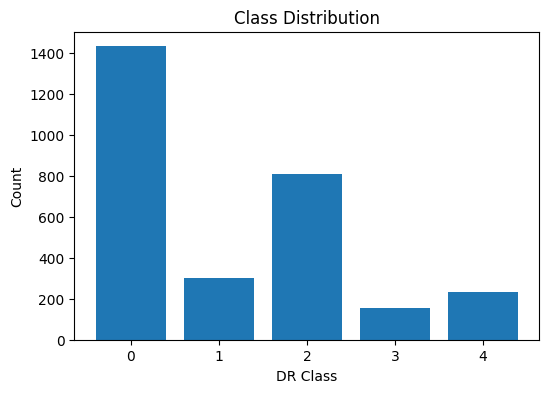

In [14]:
counts = df["diagnosis"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution")
plt.xlabel("DR Class")
plt.ylabel("Count")
plt.show()


#### Load & Display Sample Image (Robust, No Crashes)✅ If CSV-based (id_code):

In [15]:
print("BASE_DIR =", BASE_DIR)
print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("BASE_DIR contents:")
print(os.listdir(BASE_DIR))


BASE_DIR = /kaggle/input/aptos2019
BASE_DIR exists: True
BASE_DIR contents:
['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [16]:
import os

IMG_EXTS = (".png", ".jpg", ".jpeg")

candidates = []
for root, dirs, files in os.walk(BASE_DIR):
    img_count = sum(f.lower().endswith(IMG_EXTS) for f in files)
    if img_count > 50:  # threshold; images folders usually have hundreds/thousands
        candidates.append((img_count, root))

candidates = sorted(candidates, reverse=True)
print("Top image-folder candidates:")
for c, r in candidates[:10]:
    print(c, "images in ->", r)


Top image-folder candidates:
2930 images in -> /kaggle/input/aptos2019/train_images/train_images
366 images in -> /kaggle/input/aptos2019/val_images/val_images
366 images in -> /kaggle/input/aptos2019/test_images/test_images


In [17]:
IMAGE_DIR = candidates[0][1]
print("✅ Using IMAGE_DIR:", IMAGE_DIR)
print("Sample files:", os.listdir(IMAGE_DIR)[:10])


✅ Using IMAGE_DIR: /kaggle/input/aptos2019/train_images/train_images
Sample files: ['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']


In [18]:
print("CSV_PATH =", CSV_PATH)
print("CSV exists:", os.path.exists(CSV_PATH))

df = pd.read_csv(CSV_PATH)
print("Columns:", df.columns)
print(df.head(3))


CSV_PATH = /kaggle/input/aptos2019/train_1.csv
CSV exists: True
Columns: Index(['id_code', 'diagnosis'], dtype='object')
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4


In [19]:
import os

# Collect image stems from the actual IMAGE_DIR
files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(IMG_EXTS)]
stems = set(os.path.splitext(f)[0] for f in files)

# Try to detect the ID column automatically
possible_id_cols = ["id_code", "image", "image_id", "filename", "file", "id"]
id_col = None
for col in df.columns:
    if col in possible_id_cols:
        id_col = col
        break

print("Detected id column:", id_col)
print("Num images in folder:", len(files))
print("Num unique stems:", len(stems))

# If id_col not detected, print columns and choose manually
if id_col is None:
    print("⚠️ Could not auto-detect ID column. Columns are:", list(df.columns))
else:
    ids = set(df[id_col].astype(str).str.replace(".png","", regex=False)
                           .str.replace(".jpg","", regex=False)
                           .str.replace(".jpeg","", regex=False))
    overlap = len(ids.intersection(stems))
    print("Overlap between CSV IDs and image stems:", overlap)


Detected id column: id_code
Num images in folder: 2930
Num unique stems: 2930
Overlap between CSV IDs and image stems: 2930


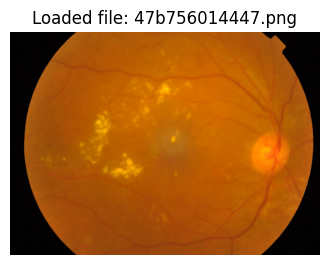

In [20]:
import random

fname = random.choice(files)
img_path = os.path.join(IMAGE_DIR, fname)

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"cv2 could not read: {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Loaded file: {fname}")
plt.axis("off")
plt.show()


In [21]:
def find_image_path_anywhere(base_dir, image_id):
    image_id = str(image_id)
    for root, dirs, files in os.walk(base_dir):
        for ext in [".png", ".jpg", ".jpeg"]:
            target = image_id + ext
            if target in files:
                return os.path.join(root, target)
    return None


Selected ID: 79ce83c07588
Found path: /kaggle/input/aptos2019/train_images/train_images/79ce83c07588.png


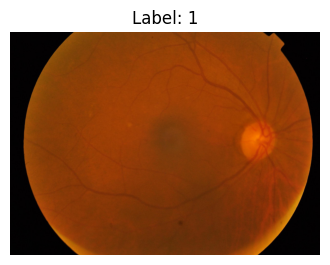

In [22]:
sample = df.sample(1).iloc[0]
image_id = sample[id_col]  # replace id_col if needed
label = sample["diagnosis"] if "diagnosis" in df.columns else "N/A"

img_path = find_image_path_anywhere(BASE_DIR, image_id)
print("Selected ID:", image_id)
print("Found path:", img_path)

if img_path is None:
    raise FileNotFoundError("Could not locate this ID anywhere under BASE_DIR.")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


Selected ID: 4ecd1fdd1435
Image path: /kaggle/input/aptos2019/train_images/train_images/4ecd1fdd1435.png


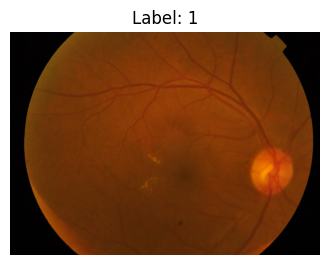

In [23]:
def find_image_path(image_dir, image_id):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = os.path.join(image_dir, image_id + ext)
        if os.path.exists(p):
            return p
    return None

sample = df.sample(1).iloc[0]
image_id = sample["id_code"]
label = sample["diagnosis"]

img_path = find_image_path(IMAGE_DIR, image_id)
print("Selected ID:", image_id)
print("Image path:", img_path)

if img_path is None:
    raise FileNotFoundError("Image not found. Check folder structure and extensions.")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


## Data Preprocessing

#### Step 4.1 — Confirm image paths (CSV-based vs folder-based)

In [24]:
print("IMAGE_DIR:", IMAGE_DIR)
print("Exists:", os.path.exists(IMAGE_DIR))
print("First 10 files:", os.listdir(IMAGE_DIR)[:10])


IMAGE_DIR: /kaggle/input/aptos2019/train_images/train_images
Exists: True
First 10 files: ['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']


In [25]:
print("First 5 id_code values:", df["id_code"].head().tolist())


First 5 id_code values: ['1ae8c165fd53', '1b329a127307', '1b32e1d775ea', '1b3647865779', '1b398c0494d1']


In [26]:
test_id = df["id_code"].iloc[0]

for ext in [".png", ".jpg", ".jpeg"]:
    p = os.path.join(IMAGE_DIR, test_id + ext)
    print(ext, "->", os.path.exists(p), p)


.png -> True /kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.png
.jpg -> False /kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.jpg
.jpeg -> False /kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.jpeg


In [27]:
IMG_EXTS = (".png", ".jpg", ".jpeg")

candidates = []
for root, dirs, files in os.walk(BASE_DIR):
    img_count = sum(f.lower().endswith(IMG_EXTS) for f in files)
    if img_count > 50:
        candidates.append((img_count, root))

candidates = sorted(candidates, reverse=True)
print("Top image-folder candidates:")
for c, r in candidates[:10]:
    print(c, "images in ->", r)

IMAGE_DIR = candidates[0][1]
print("✅ Updated IMAGE_DIR:", IMAGE_DIR)
print("Sample files:", os.listdir(IMAGE_DIR)[:10])


Top image-folder candidates:
2930 images in -> /kaggle/input/aptos2019/train_images/train_images
366 images in -> /kaggle/input/aptos2019/val_images/val_images
366 images in -> /kaggle/input/aptos2019/test_images/test_images
✅ Updated IMAGE_DIR: /kaggle/input/aptos2019/train_images/train_images
Sample files: ['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']


#### Step 4.2 — Core preprocessing functions (the “correct” pipeline)

In [28]:
import numpy as np
import cv2

def crop_black_borders(img, tol=7):
    """
    Remove black borders by finding non-dark pixels.
    Works best for fundus images with black background.
    """
    if img is None:
        return None
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img  # fallback
    
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def apply_clahe_rgb(img_rgb, clip_limit=2.0, tile_grid_size=(8,8)):
    """
    Apply CLAHE on L channel in LAB color space.
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def preprocess_fundus(
    img_bgr,
    out_size=(224, 224),
    do_crop=True,
    do_denoise=True,
    do_clahe=True
):
    """
    Input: BGR image from cv2.imread
    Output: float32 RGB image normalized to [0,1] with shape (H,W,3)
    """
    if img_bgr is None:
        return None
    
    # Convert BGR->RGB
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Crop borders
    if do_crop:
        img = crop_black_borders(img)

    # Resize
    img = cv2.resize(img, out_size, interpolation=cv2.INTER_AREA)

    # Denoise (light)
    if do_denoise:
        img = cv2.fastNlMeansDenoisingColored(img, None, 3, 3, 7, 21)

    # CLAHE
    if do_clahe:
        img = apply_clahe_rgb(img, clip_limit=2.0, tile_grid_size=(8,8))

    # Normalize to [0,1]
    img = img.astype(np.float32) / 255.0

    return img


In [29]:
print("crop_black_borders:", crop_black_borders)
print("apply_clahe_rgb:", apply_clahe_rgb)
print("preprocess_fundus:", preprocess_fundus)


crop_black_borders: <function crop_black_borders at 0x7a956864d9e0>
apply_clahe_rgb: <function apply_clahe_rgb at 0x7a956864efc0>
preprocess_fundus: <function preprocess_fundus at 0x7a956864cea0>


Selected ID: 8ead17dfb6a6
Found path: /kaggle/input/aptos2019/train_images/train_images/8ead17dfb6a6.png
Processed shape: (224, 224, 3) dtype: float32 min: 0.0 max: 1.0


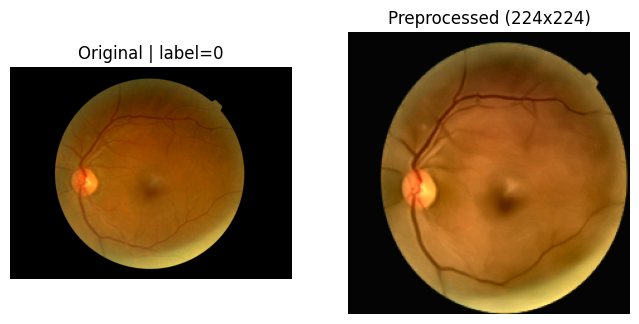

In [30]:
# pick one sample row
row = df.sample(1).iloc[0]
image_id = row["id_code"]
label = row["diagnosis"]

# try common extensions
def find_image_path(image_dir, image_id):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = os.path.join(image_dir, str(image_id) + ext)
        if os.path.exists(p):
            return p
    return None

img_path = find_image_path(IMAGE_DIR, image_id)
print("Selected ID:", image_id)
print("Found path:", img_path)

if img_path is None:
    raise FileNotFoundError("Could not find image for this id_code in IMAGE_DIR.")

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"cv2 could not read this file: {img_path}")

# preprocess (this is Step 4.2 in action)
proc = preprocess_fundus(img_bgr, out_size=(224,224))

print("Processed shape:", proc.shape, "dtype:", proc.dtype,
      "min:", proc.min(), "max:", proc.max())

# show before/after
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Original | label={label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(proc)
plt.title("Preprocessed (224x224)")
plt.axis("off")

plt.show()


In [31]:
print("✅ Preprocessing functions defined successfully")


✅ Preprocessing functions defined successfully


### Step 4.3 — Image quality checks (optional but recommended)

In [32]:
def is_low_quality(img_rgb_01, blur_thresh=25.0, dark_thresh=0.08):
    """
    img_rgb_01: RGB float image in [0,1]
    Returns True if image likely too dark or too blurry.
    """
    if img_rgb_01 is None:
        return True

    img_uint8 = (img_rgb_01 * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Darkness check
    mean_intensity = gray.mean() / 255.0
    if mean_intensity < dark_thresh:
        return True

    # Blur check (variance of Laplacian)
    fm = cv2.Laplacian(gray, cv2.CV_64F).var()
    if fm < blur_thresh:
        return True

    return False


In [33]:
print("✅ is_low_quality function loaded:", is_low_quality)


✅ is_low_quality function loaded: <function is_low_quality at 0x7a95686c6660>


In [34]:
IMG_EXTS = (".png", ".jpg", ".jpeg")

print("IMAGE_DIR =", IMAGE_DIR)
print("Exists:", os.path.exists(IMAGE_DIR))

files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(IMG_EXTS)]
print("Number of image files found:", len(files))

# Pick the first file (guaranteed)
fname = files[0]
img_path = os.path.join(IMAGE_DIR, fname)
print("Sample file:", fname)
print("Sample path:", img_path)


IMAGE_DIR = /kaggle/input/aptos2019/train_images/train_images
Exists: True
Number of image files found: 2930
Sample file: 6dcde47060f9.png
Sample path: /kaggle/input/aptos2019/train_images/train_images/6dcde47060f9.png


cv2.imread result is None? False
Processed shape: (224, 224, 3)
Processed range: 0.0 to 1.0
✅ Low quality? False


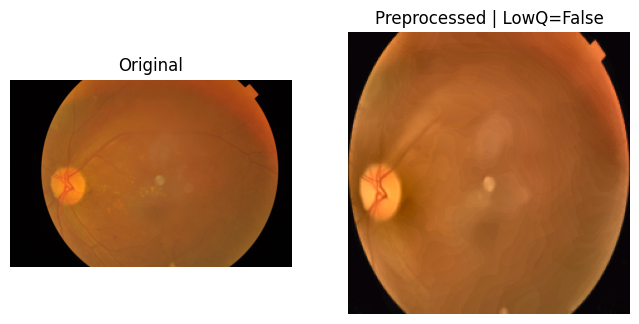

In [35]:
img_bgr = cv2.imread(img_path)
print("cv2.imread result is None?", img_bgr is None)

# If it is None, it's a path/permission/corrupt-file issue
if img_bgr is None:
    raise FileNotFoundError(f"OpenCV could not read: {img_path}")

proc = preprocess_fundus(img_bgr, out_size=(224,224))

print("Processed shape:", proc.shape)
print("Processed range:", proc.min(), "to", proc.max())

lowq = is_low_quality(proc)
print("✅ Low quality?", lowq)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(proc)
plt.title(f"Preprocessed | LowQ={lowq}")
plt.axis("off")
plt.show()


### Step 4.4 — Test preprocessing on one sample (no more guessing)
#### If you have id_code + IMAGE_DIR

ID: a2811f512c1c | Found: /kaggle/input/aptos2019/train_images/train_images/a2811f512c1c.png
Label: 0 | Low quality? False


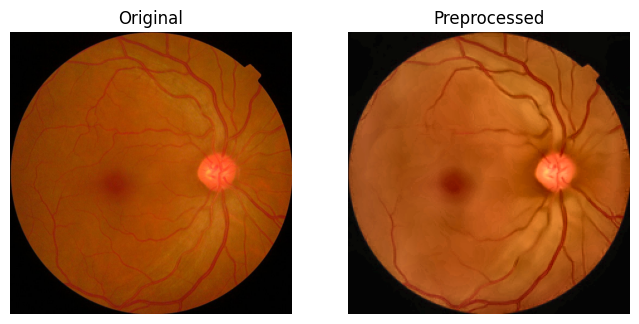

In [36]:
sample = df.sample(1).iloc[0]
image_id = sample["id_code"]
label = sample["diagnosis"]

img_path = find_image_path(IMAGE_DIR, image_id)
print("ID:", image_id, "| Found:", img_path)

if img_path is None:
    raise FileNotFoundError("Could not locate image for this id_code. Check IMAGE_DIR and extensions.")

img_bgr = cv2.imread(img_path)
proc = preprocess_fundus(img_bgr, out_size=(224,224))

print("Label:", label, "| Low quality?", is_low_quality(proc))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(proc)
plt.title("Preprocessed")
plt.axis("off")
plt.show()


### Step 4.5 — Build a cleaned dataframe (flag/remove low-quality)

In [37]:
def get_img_path_from_row(row):
    if "path" in row.index:
        return row["path"]
    return find_image_path(IMAGE_DIR, row["id_code"])

keeps = []
missing = 0

for _, row in df.sample(min(len(df), 500)).iterrows():  # sample 500 for fast check (you can do full later)
    p = get_img_path_from_row(row)
    if p is None:
        missing += 1
        keeps.append(False)
        continue
    img_bgr = cv2.imread(p)
    proc = preprocess_fundus(img_bgr, out_size=(224,224))
    keeps.append(not is_low_quality(proc))

print("Missing images in sample:", missing)
print("Keep ratio in sample:", np.mean(keeps))


Missing images in sample: 0
Keep ratio in sample: 1.0


## PHASE 5: Dataset Class, Transforms, DataLoaders (PyTorch)

#### Step 5.2 — Robust path resolver (no more “image not found” crashes)

In [38]:
IMG_EXTS = (".png", ".jpg", ".jpeg")

def find_image_path(image_dir, image_id):
    image_id = str(image_id)
    for ext in IMG_EXTS:
        p = os.path.join(image_dir, image_id + ext)
        if os.path.exists(p):
            return p
    return None


#### Step 5.3 — PyTorch transforms (augmentation + normalization)

In [39]:
import torchvision.transforms as T

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = T.Compose([
    T.ToTensor(),                      # (H,W,C)->(C,H,W), [0,1]
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


#### Step 5.4 — Custom Dataset Class (core of Phase 5)

In [40]:
class APTOSDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["id_code"]
        label = int(row["diagnosis"])

        img_path = find_image_path(self.image_dir, image_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for id_code: {image_id}")

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"cv2 failed to read: {img_path}")

        img = preprocess_fundus(img_bgr, out_size=(224,224))  # Phase 4
        if img is None:
            raise ValueError(f"Preprocessing failed for: {img_path}")

        # img is RGB float in [0,1]
        if self.transform:
            img = self.transform(img)

        return img, label


#### Step 5.5 — Train/Validation Split (stratified)

In [41]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["diagnosis"]
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Train class distribution:\n", train_df["diagnosis"].value_counts().sort_index())
print("Val class distribution:\n", val_df["diagnosis"].value_counts().sort_index())


Train size: 2344
Val size: 586
Train class distribution:
 diagnosis
0    1147
1     240
2     647
3     123
4     187
Name: count, dtype: int64
Val class distribution:
 diagnosis
0    287
1     60
2    161
3     31
4     47
Name: count, dtype: int64


#### Step 5.6 — DataLoaders

In [42]:
BATCH_SIZE = 16  # start here; reduce if CUDA OOM
NUM_WORKERS = 2  # Kaggle usually safe

train_ds = APTOSDataset(train_df, IMAGE_DIR, transform=train_tfms)
val_ds   = APTOSDataset(val_df, IMAGE_DIR, transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✅ DataLoaders ready")


✅ DataLoaders ready


#### Step 5.7 — Sanity check: One batch

In [43]:
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)  # expected: [B, 3, 224, 224]
print("Batch labels shape:", labels.shape)  # expected: [B]
print("Labels sample:", labels[:10].tolist())


Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Labels sample: [0, 0, 2, 0, 1, 0, 0, 1, 2, 2]


## PHASE 6: Model Building (Baseline CNN → Hybrid CNN + ViT)

### Step 6.1 — Imports (torchvision models)

In [44]:
import torchvision
import torchvision.models as models
print("torchvision:", torchvision.__version__)


torchvision: 0.21.0+cu124


### Step 6.2 — Baseline Model 1: ResNet-50 (strong standard baseline)
### Build ResNet50 with 5 output classes

In [46]:
NUM_CLASSES = 5

resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet50.fc = nn.Linear(resnet50.fc.in_features, NUM_CLASSES)
resnet50 = resnet50.to(device)

print("✅ ResNet50 ready")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


✅ ResNet50 ready


### Quick forward-pass test (no training)

In [47]:
resnet50.eval()
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    logits = resnet50(images)

print("Logits shape:", logits.shape)  # expected: [B, 5]


Logits shape: torch.Size([16, 5])


### Step 6.3 — Baseline Model 2 (optional but recommended): EfficientNet-B0
### EfficientNet often works well on fundus data.

In [48]:
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
effnet = effnet.to(device)

effnet.eval()
with torch.no_grad():
    logits = effnet(images)

print("EfficientNet logits shape:", logits.shape)  # [B, 5]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 240MB/s]


EfficientNet logits shape: torch.Size([16, 5])


### Step 6.4 — Hybrid CNN + ViT (Simple & Correct)
### Hybrid Model Definition (PyTorch)

In [49]:
class HybridCNNViT(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()

        # CNN Backbone (use resnet18 for lighter hybrid)
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(backbone.children())[:-2])  # output: [B, 512, H/32, W/32]
        cnn_out_channels = 512

        # Project CNN channels -> Transformer embed dim
        self.proj = nn.Conv2d(cnn_out_channels, embed_dim, kernel_size=1)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # x: [B,3,224,224]
        f = self.cnn(x)           # [B,512,7,7] for 224 input
        f = self.proj(f)          # [B,embed_dim,7,7]

        B, C, H, W = f.shape
        tokens = f.flatten(2).transpose(1, 2)  # [B, H*W, C] = [B, 49, embed_dim]

        # Transformer
        z = self.transformer(tokens)           # [B,49,embed_dim]

        # Global average pooling over tokens
        z = z.mean(dim=1)                      # [B,embed_dim]

        # Class logits
        out = self.cls_head(z)                 # [B,num_classes]
        return out


### Step 6.5 — Instantiate Hybrid Model + Forward Pass Test

In [50]:
hybrid_model = HybridCNNViT(num_classes=NUM_CLASSES).to(device)
hybrid_model.eval()

with torch.no_grad():
    hybrid_logits = hybrid_model(images)

print("✅ Hybrid logits shape:", hybrid_logits.shape)  # expected [B,5]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 248MB/s]


✅ Hybrid logits shape: torch.Size([16, 5])


## PHASE 7: Training Loop (Loss, Optimizer, Scheduler, Metrics, Checkpoints)

### Step 7.1 — Helper: one function to compute metrics
### DR is ordinal, so we include QWK (Quadratic Weighted Kappa).

In [51]:
from sklearn.metrics import cohen_kappa_score

def compute_metrics(y_true, y_pred, y_prob=None):
    """
    y_true: list[int]
    y_pred: list[int]
    y_prob: optional np.array (N, num_classes) for AUC
    """
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    out = {"acc": acc, "f1_macro": f1, "recall_macro": rec, "precision_macro": prec, "qwk": qwk}

    # Optional: multi-class AUC (only if probabilities are provided)
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
            out["auc_ovr"] = auc
        except Exception:
            pass

    return out


In [52]:
# Quick unit test for compute_metrics
y_true = [0, 0, 1, 2, 2, 3, 4]
y_pred = [0, 1, 1, 2, 2, 3, 4]

m = compute_metrics(y_true, y_pred)
print("✅ compute_metrics output:")
print(m)


✅ compute_metrics output:
{'acc': 0.8571428571428571, 'f1_macro': 0.8666666666666666, 'recall_macro': 0.9, 'precision_macro': 0.9, 'qwk': 0.9590643274853801}


### Step 7.2 — Class weights for imbalance (recommended)

In [53]:
# Compute class weights from training set
class_counts = train_df["diagnosis"].value_counts().sort_index()
total = class_counts.sum()
weights = total / (len(class_counts) * class_counts.values)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts.to_dict())
print("Class weights:", weights)


Class counts: {0: 1147, 1: 240, 2: 647, 3: 123, 4: 187}
Class weights: [0.4087184  1.95333333 0.72457496 3.81138211 2.50695187]


### Loss function:

In [54]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


class_counts = train_df["diagnosis"].value_counts().sort_index()
print("✅ Class counts (train_df):")
print(class_counts)
print("Total samples:", int(class_counts.sum()))


#### 1) Print class counts

In [55]:
class_counts = train_df["diagnosis"].value_counts().sort_index()
print("✅ Class counts (train_df):")
print(class_counts)
print("Total samples:", int(class_counts.sum()))


✅ Class counts (train_df):
diagnosis
0    1147
1     240
2     647
3     123
4     187
Name: count, dtype: int64
Total samples: 2344


#### 2) Compute & print class weights

In [56]:
total = class_counts.sum()
weights = total / (len(class_counts) * class_counts.values)

print("\n✅ Raw weights array:")
print(weights)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("\n✅ class_weights tensor:")
print(class_weights)
print("Device:", class_weights.device)
print("Dtype:", class_weights.dtype)



✅ Raw weights array:
[0.4087184  1.95333333 0.72457496 3.81138211 2.50695187]

✅ class_weights tensor:
tensor([0.4087, 1.9533, 0.7246, 3.8114, 2.5070], device='cuda:0')
Device: cuda:0
Dtype: torch.float32


#### 3) Create loss function and print it

In [57]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("\n✅ Loss function created:")
print(criterion)



✅ Loss function created:
CrossEntropyLoss()


### Step 7.3 — Optimizer + Scheduler

In [58]:
def build_optimizer(model, lr=1e-4, weight_decay=1e-4):
    return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def build_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2, verbose=True
    )


### Step 7.4 — One Epoch Train Function

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(y_true, y_pred)

    return avg_loss, metrics


### Step 7.5 — Validation Function (collect probs)

In [60]:
import numpy as np

def validate(model, loader, criterion, device, num_classes=5):
    model.eval()
    total_loss = 0.0

    y_true, y_pred = [], []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)
            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.append(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_prob = np.vstack(y_prob)

    metrics = compute_metrics(y_true, y_pred, y_prob=y_prob)
    return avg_loss, metrics


### Step 7.6 — Full Training Loop with Checkpointing

In [61]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=10,
    save_path="/kaggle/working/models/best_model.pt",
):
    best_qwk = -1.0
    history = []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_metrics = validate(model, val_loader, criterion, device)

        scheduler.step(val_metrics["qwk"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} val_f1={val_metrics['f1_macro']:.4f} val_acc={val_metrics['acc']:.4f}"
        )

        # Save best model
        if val_metrics["qwk"] > best_qwk:
            best_qwk = val_metrics["qwk"]
            torch.save(model.state_dict(), save_path)
            print(f"✅ Saved best model to {save_path} (best_qwk={best_qwk:.4f})")

    return history, best_qwk


### Step 7.7 — Run Training (choose which model)
### Example: train ResNet50

In [62]:
model = resnet50  # or effnet or hybrid_model
optimizer = build_optimizer(model, lr=1e-4, weight_decay=1e-4)
scheduler = build_scheduler(optimizer)

history, best_qwk = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    save_path=os.path.join(MODEL_DIR, "best_resnet50.pt"),
)


Epoch 01 | train_loss=1.2620 val_loss=0.9998 | val_qwk=0.8173 val_f1=0.5045 val_acc=0.6706
✅ Saved best model to /kaggle/working/models/best_resnet50.pt (best_qwk=0.8173)
Epoch 02 | train_loss=0.9226 val_loss=0.8768 | val_qwk=0.8509 val_f1=0.6189 val_acc=0.7645
✅ Saved best model to /kaggle/working/models/best_resnet50.pt (best_qwk=0.8509)
Epoch 03 | train_loss=0.8130 val_loss=0.8501 | val_qwk=0.8742 val_f1=0.6484 val_acc=0.7816
✅ Saved best model to /kaggle/working/models/best_resnet50.pt (best_qwk=0.8742)
Epoch 04 | train_loss=0.6982 val_loss=0.8213 | val_qwk=0.8424 val_f1=0.6423 val_acc=0.7628
Epoch 05 | train_loss=0.6245 val_loss=0.8327 | val_qwk=0.8880 val_f1=0.6600 val_acc=0.7850
✅ Saved best model to /kaggle/working/models/best_resnet50.pt (best_qwk=0.8880)
Epoch 06 | train_loss=0.5039 val_loss=0.8201 | val_qwk=0.8721 val_f1=0.6406 val_acc=0.7765
Epoch 07 | train_loss=0.4071 val_loss=0.7971 | val_qwk=0.8869 val_f1=0.6731 val_acc=0.7918
Epoch 08 | train_loss=0.3619 val_loss=0.890

In [64]:
hist_df = pd.DataFrame(history)
hist_df.to_csv(os.path.join(RESULTS_DIR, "resnet50_history.csv"), index=False)
print("✅ Saved resnet50_history.csv")


✅ Saved resnet50_history.csv


In [65]:
hist_df = pd.DataFrame(history)
hist_path = os.path.join(RESULTS_DIR, "resnet50_history_run2.csv")
hist_df.to_csv(hist_path, index=False)
print("✅ Saved:", hist_path)


✅ Saved: /kaggle/working/results/resnet50_history_run2.csv


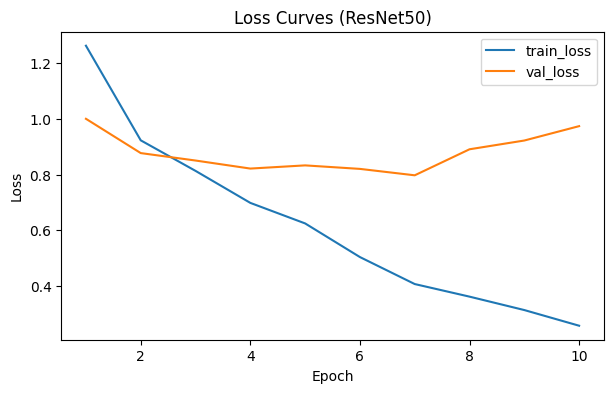

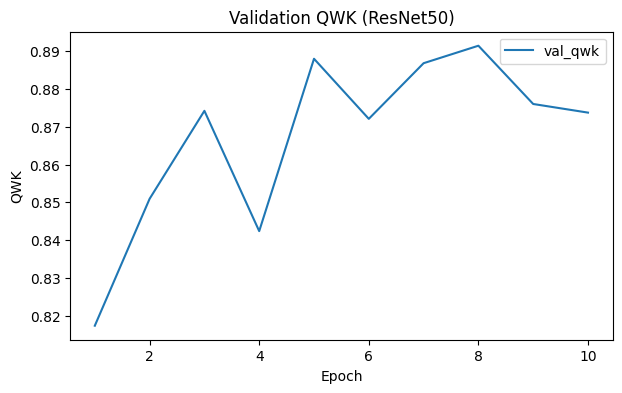

In [66]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves (ResNet50)")
plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["val_qwk"], label="val_qwk")
plt.xlabel("Epoch"); plt.ylabel("QWK"); plt.title("Validation QWK (ResNet50)")
plt.legend(); plt.show()


In [67]:
import os
print(os.listdir("/kaggle"))
print(os.listdir("/kaggle/working"))
print(os.listdir("/kaggle/working/results"))


['lib', 'input', 'working']
['models', '.virtual_documents', 'results']
['resnet50_history_run2.csv', 'heatmaps', 'resnet50_history.csv']


In [68]:
import os
print("kaggle root:", os.listdir("/kaggle"))
print("working:", os.listdir("/kaggle/working"))
print("results:", os.listdir("/kaggle/working/results"))


kaggle root: ['lib', 'input', 'working']
working: ['models', '.virtual_documents', 'results']
results: ['resnet50_history_run2.csv', 'heatmaps', 'resnet50_history.csv']


### Old Work

In [ ]:
# Core libraries (pre-installed on Kaggle)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

# PyTorch ecosystem (pre-installed)
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Additional libraries (already available)
import timm  # For pre-trained models (e.g., ViT, EfficientNet)
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Image Loading & Visualization

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

base_dir = "/kaggle/input/aptos2019"

# -----------------------
# CSVs for train/val/test
# -----------------------
train_csv = os.path.join(base_dir, "train_1.csv")
val_csv   = os.path.join(base_dir, "valid.csv")
test_csv  = os.path.join(base_dir, "test.csv")

# -----------------------
# Folders for images
# -----------------------
train_img_dir = os.path.join(base_dir, "train_images", "train_images")
val_img_dir   = os.path.join(base_dir, "val_images")
test_img_dir  = os.path.join(base_dir, "test_images")

# -----------------------
# Load CSV
# -----------------------
df = pd.read_csv(train_csv)
print(df.head())

# -----------------------
# Pick an example (first row)
# -----------------------
example_id = df['id_code'].iloc[0]
example_label = df['diagnosis'].iloc[0]

# -----------------------
# Safe image path (PNG or JPG)
# -----------------------
png_path = os.path.join(train_img_dir, example_id + ".png")
jpg_path = os.path.join(train_img_dir, example_id + ".jpg")

if os.path.exists(png_path):
    image_path = png_path
elif os.path.exists(jpg_path):
    image_path = jpg_path
else:
    raise FileNotFoundError(f"Image not found! Tried:\n{png_path}\n{jpg_path}")

print("Loading:", image_path)

# -----------------------
# Load and display image
# -----------------------
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {example_label}")
plt.show()


## Image Resizing & Normalization

In [ ]:
# -----------------------
# Step 2: Resize & Normalize a single image
# -----------------------

# Target size for your model
target_size = (224, 224)

# Resize
resized = cv2.resize(image, target_size)

# Normalize 0-1
normalized = resized / 255.0

# Fancy ImageNet normalization
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
normalized_fancy = (normalized - mean) / std

# -----------------------
# Display
# -----------------------
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(resized)
axs[0].set_title("Resized")
axs[0].axis("off")

axs[1].imshow(normalized)
axs[1].set_title("Normalized 0–1")
axs[1].axis("off")
plt.show()


## Noise Removal & Contrast Enhancement (CLAHE)

In [ ]:
# -----------------------
# Step 3: Denoising + CLAHE enhancement
# -----------------------

# Apply Gaussian blur to reduce noise
denoised = cv2.GaussianBlur(resized, (5,5), 0)

# Convert to LAB color space
lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

# Apply CLAHE on L-channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_l = clahe.apply(l)

# Merge channels back
enhanced_lab = cv2.merge((enhanced_l, a, b))
enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

# -----------------------
# Display before and after
# -----------------------
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(resized)
axs[0].set_title("Before CLAHE")
axs[0].axis("off")

axs[1].imshow(enhanced)
axs[1].set_title("After CLAHE")
axs[1].axis("off")
plt.show()


## Handling Poor-Quality Images

In [ ]:
# -----------------------
# Step 4: Crop based on largest contour + resize + blurriness
# -----------------------

# Convert to grayscale for contour detection
gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

# Threshold to find main region
_, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Crop to largest contour if exists
if contours:
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    cropped = enhanced[y:y+h, x:x+w]
    # Resize back to model input size
    cropped = cv2.resize(cropped, (224,224))
else:
    # Fallback: use full enhanced image
    cropped = cv2.resize(enhanced, (224,224))

# Compute blurriness (Laplacian variance)
blurriness = cv2.Laplacian(gray, cv2.CV_64F).var()
print("Blurriness:", blurriness)  # Lower = blurry

# -----------------------
# Display cropped image
# -----------------------
plt.figure(figsize=(6,6))
plt.imshow(cropped)
plt.axis("off")
plt.title("Cropped & Resized")
plt.show()


## Data Augmentation (Why + How)

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -----------------------
# Step 5: Define augmentation pipeline
# -----------------------
transform = A.Compose([
    A.Rotate(limit=45, p=0.5),                  # Random rotation
    A.HorizontalFlip(p=0.5),                    # Random horizontal flip
    A.RandomBrightnessContrast(p=0.5),          # Random brightness/contrast
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),   # ImageNet normalization
    ToTensorV2()                                # Convert to PyTorch tensor
])

# Apply augmentation to the cropped image
augmented = transform(image=cropped)['image']

# -----------------------
# Display augmented image
# -----------------------
plt.figure(figsize=(6,6))
plt.imshow(augmented.permute(1,2,0))  # CHW -> HWC for matplotlib
plt.axis("off")
plt.title("Augmented")
plt.show()


## Train / Validation / Test Split

In [ ]:
# Already loaded earlier
train_df = pd.read_csv(os.path.join(base_dir, "train_1.csv"))
val_df   = pd.read_csv(os.path.join(base_dir, "valid.csv"))
test_df  = pd.read_csv(os.path.join(base_dir, "test.csv"))

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))


## Handling Class Imbalance

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Use only training labels for class weights
classes = np.unique(train_df['diagnosis'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['diagnosis'])
class_weights = dict(zip(classes, weights))

print("Class weights (for training):", class_weights)


In [ ]:
import torch.nn as nn

weights_tensor = torch.tensor(list(class_weights.values()), dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)


## Full Pipeline: Custom Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import cv2
import os

# -----------------------
# Transforms
# -----------------------
train_transform = A.Compose([
    A.Rotate(limit=45, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# -----------------------
# Custom Dataset
# -----------------------
class DRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df['id_code'].iloc[idx]

        # Try PNG first, fallback to JPG
        img_path = os.path.join(self.image_dir, img_id + '.png')
        if not os.path.exists(img_path):
            img_path = os.path.join(self.image_dir, img_id + '.jpg')

        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Core preprocessing
        image = cv2.resize(image, (224, 224))
        image = cv2.GaussianBlur(image, (5, 5), 0)

        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # Crop black borders if present
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
            image = image[max(y,0):y+h, max(x,0):x+w]
            image = cv2.resize(image, (224, 224))

        label = torch.tensor(self.df['diagnosis'].iloc[idx], dtype=torch.long)

        # Apply Albumentations transforms if provided
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

# -----------------------
# Create datasets (use correct folders)
# -----------------------
train_dataset = DRDataset(train_df, train_img_dir, transform=train_transform)
val_dataset   = DRDataset(val_df, val_img_dir, transform=val_transform)
test_dataset  = DRDataset(test_df, test_img_dir, transform=val_transform)

# -----------------------
# DataLoaders
# -----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Pipeline ready! Train batches:", len(train_loader))


In [ ]:
# Test one batch
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)  # Should be [batch_size, 3, 224, 224]
print("Labels:", labels)

# Visualize first image in batch (convert back for plotting)
plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())  # Denormalize if needed for better view
plt.title(f"Sample from Train Loader - Label: {labels[0].item()}")
plt.show()

### Phase 5

In [ ]:
import torch
import torch.nn as nn
import timm  # From PHASE 3 setup

class HybridCNNViT(nn.Module):
    def __init__(self, num_classes=5, cnn_model='efficientnet_b0', num_transformer_layers=2, embed_dim=384, num_heads=6):
        super(HybridCNNViT, self).__init__()
        
        # Step 1: CNN Backbone (feature extractor)
        self.cnn = timm.create_model(cnn_model, pretrained=True, features_only=True)  # Pre-trained on ImageNet
        # Get the output channels from the last feature map (for EfficientNet-B0, it's 1280)
        self.cnn_out_channels = self.cnn.feature_info[-1]['num_chs']  # Dynamic for different backbones
        
        # Step 2: Projection to embed_dim (for ViT input)
        self.projection = nn.Conv2d(self.cnn_out_channels, embed_dim, kernel_size=1)  # 1x1 conv to match dimensions
        
        # Step 3: Positional embeddings (learnable for flexibility)
        self.pos_embed = nn.Parameter(torch.zeros(1, 49, embed_dim))  # Assuming 7x7 = 49 "patches" from CNN features
        
        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4, dropout=0.1)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        # Step 4: Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)  # Output logits for 5 classes
        )
    
    def forward(self, x):
        # CNN feature extraction
        features = self.cnn(x)[-1]  # Get the deepest feature map (e.g., [batch, 1280, 7, 7])
        
        # Project to embed_dim
        features = self.projection(features)  # [batch, embed_dim, 7, 7]
        
        # Flatten to sequence for ViT (treat as 49 "patches")
        features = features.flatten(2)  # [batch, embed_dim, 49]
        features = features.transpose(1, 2)  # [batch, 49, embed_dim]
        
        # Add positional embeddings
        features = features + self.pos_embed
        
        # Transformer encoder (global attention)
        features = self.transformer_encoder(features)  # [batch, 49, embed_dim]
        
        # Pool and classify
        features = features.mean(dim=1)  # Global average pooling [batch, embed_dim]
        out = self.head(features)  # [batch, 5]
        
        return out

# Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCNNViT(num_classes=5).to(device)
print(model)  # Print architecture to verify

### Phase 6

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import time

# ──── Loss with class weights (from Phase 4) ────
class_weights_tensor = torch.tensor(list(class_weights.values()), dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ──── Optimizer & Scheduler ────
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# ──── Early stopping parameters ────
patience = 7
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

# ──── Training history ────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

num_epochs = 30

for epoch in range(num_epochs):
    start_time = time.time()
    
    # ──── Training phase ────
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_acc = 100 * correct / total
    
    # ──── Validation phase ────
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = 100 * val_correct / val_total
    
    # ──── Save history ────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # ──── Scheduler & early stopping ────
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"New best model at epoch {epoch+1}")
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")

# ──── Load best model for further use ────
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "/kaggle/working/best_hybrid_model.pth")
print("Training finished. Best model saved.")